# SAM Automatic Mask Generation：全圖自動分割（不使用 ROI/box prompt）

`sigle_image.ipynb` 示範的是 **box-prompt** 流程：先框出一顆目標牙齒，SAM 再回傳該區域內的 mask。

這份 notebook 改用 SAM 的 `SamAutomaticMaskGenerator`：它在整張影像上撒一組 grid points，對每個點各自跑 mask decoder，再依 IoU 分數、穩定度、NMS 去除重複，最後回傳「整張圖」被切成的所有區域，不需要手動指定 box。

目的是觀察 **邊緣分割品質**（牙齒與牙齒之間、牙齒與齒槽骨之間的邊界是否乾淨），而不是產生可直接用的 ROI，所以這裡：

1. 不畫任何 box prompt。
2. 把 SAM 找到的每個區域塗上不同顏色（實心 overlay + 純輪廓線兩種視圖）。
3. 用未微調的通用 SAM ViT-B 權重（`~/.cache/tooth_ratio/sam_vit_b_01ec64.pth`）——目前專案裡還沒有牙科專用的 SAM 權重（`finetune_sam.py` 是尚未執行的訓練腳本）。

> 這是探索性的分割效果檢查，SAM 分出來的區域不等於解剖學上有意義的「一顆牙」，也不代表可直接拿去算 CRR。

## 0. 環境準備

In [1]:
from pathlib import Path
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK TC", "Noto Sans CJK SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path.cwd()
IMAGE_PATH = PROJECT_ROOT / "data/raw_images/1.jpg"
CHECKPOINT_PATH = Path.home() / ".cache/tooth_ratio/sam_vit_b_01ec64.pth"
OUTPUT_DIR = PROJECT_ROOT / "reports/single_image/auto_seg"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert IMAGE_PATH.exists(), f"找不到影像：{IMAGE_PATH}"
assert CHECKPOINT_PATH.exists(), f"找不到 SAM checkpoint：{CHECKPOINT_PATH}"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print({"image": str(IMAGE_PATH), "checkpoint": str(CHECKPOINT_PATH), "device": DEVICE})

{'image': '/home/cliffyang/Program/Medical-CV/tooth_ratio/data/raw_images/1.jpg', 'checkpoint': '/home/cliffyang/.cache/tooth_ratio/sam_vit_b_01ec64.pth', 'device': 'cuda'}


## 1. 讀取影像

維持原始解析度與長寬比，灰階牙科 X-ray 複製成三通道給 SAM 使用（做法與 `sigle_image.ipynb` 一致，僅做 1–99 百分位正規化，不做 CLAHE，避免額外增強改變邊緣觀察結果）。

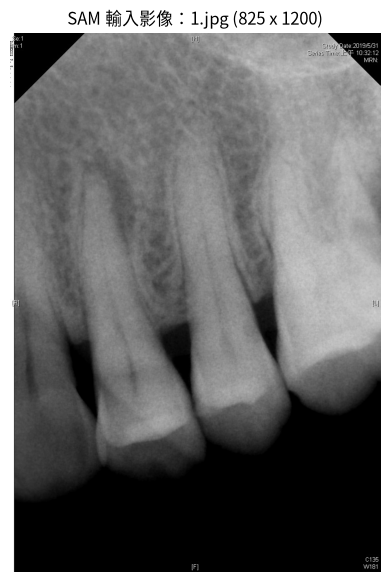

In [2]:
def percentile_normalize(image: np.ndarray, low: float = 1.0, high: float = 99.0) -> np.ndarray:
    lo, hi = np.percentile(image, [low, high])
    if hi <= lo:
        return image.copy()
    normalized = (image.astype(np.float32) - lo) / (hi - lo)
    return (np.clip(normalized, 0, 1) * 255).astype(np.uint8)


image_bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise ValueError(f"OpenCV 無法讀取：{IMAGE_PATH}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

normalized_gray = percentile_normalize(gray)
sam_image = cv2.cvtColor(normalized_gray, cv2.COLOR_GRAY2RGB)

fig, ax = plt.subplots()
ax.imshow(sam_image)
ax.set_title(f"SAM 輸入影像：{IMAGE_PATH.name} ({w} x {h})")
ax.axis("off")
plt.show()

## 2. 載入 SAM ViT-B 與 Automatic Mask Generator

重要參數（針對牙科 X-ray 這種灰階、邊界細碎的影像做了調整，而不是用 SAM 預設值）：

- `points_per_side`：撒點密度，越高越能抓到小區域（例如單顆牙根），但速度變慢。
- `pred_iou_thresh` / `stability_score_thresh`：分數門檻，調低可保留更多候選區域（含品質較差的），方便觀察 SAM 在模糊邊界上的失敗案例；調高則只留下 SAM 有信心的區域。
- `min_mask_region_area`：去除過小的雜訊區域（單位為 pixel）。
- `crop_n_layers`：是否做多尺度裁切再分割，`0` 代表只在整張圖跑一次，先用最簡單設定觀察效果。

先用一組中等設定跑一次，再視結果調整。

In [3]:
sam = sam_model_registry["vit_b"](checkpoint=str(CHECKPOINT_PATH))
sam.to(device=DEVICE)
sam.eval()

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.90,
    min_mask_region_area=200,
    crop_n_layers=0,
)

if DEVICE == "cuda":
    allocated_gb = torch.cuda.memory_allocated() / 1024**3
    print(f"SAM 已載入 GPU；目前配置約 {allocated_gb:.2f} GiB")
else:
    print("SAM 使用 CPU；流程相同，但推論會慢很多（points_per_side=32 建議先降低）。")

SAM 已載入 GPU；目前配置約 0.35 GiB


## 3. 執行全圖自動分割

`generate()` 會對整張圖跑完整個 grid，回傳一組 dict list，每個 dict 至少包含：

- `segmentation`：bool mask（與原圖同尺寸）
- `area`：mask 面積（pixel）
- `predicted_iou`：SAM 自估的 mask 品質
- `stability_score`：對 mask threshold 擾動的穩定度

In [4]:
start = time.perf_counter()
with torch.inference_mode():
    masks = mask_generator.generate(sam_image)
elapsed = time.perf_counter() - start

masks = sorted(masks, key=lambda m: m["area"], reverse=True)
areas = np.array([m["area"] for m in masks])

print(f"找到 {len(masks)} 個區域，耗時 {elapsed:.1f} 秒")
print(f"面積範圍：min={areas.min() if len(areas) else 0}, max={areas.max() if len(areas) else 0}, "
      f"median={int(np.median(areas)) if len(areas) else 0}")
print(f"影像總面積：{h * w}（最大 mask 佔比 {areas.max() / (h * w):.3f}）" if len(areas) else "沒有找到任何區域")

找到 17 個區域，耗時 3.4 秒
面積範圍：min=321, max=716429, median=6921
影像總面積：990000（最大 mask 佔比 0.724）


## 4. 視覺化：每個區域填不同顏色

顏色只用來區分不同區域，沒有語義意義（不代表「這是牙冠」「這是牙根」）。由於區域常有重疊，畫的順序是由大到小，讓大區域先鋪底、小區域蓋在上面，避免大 mask 蓋掉細節。

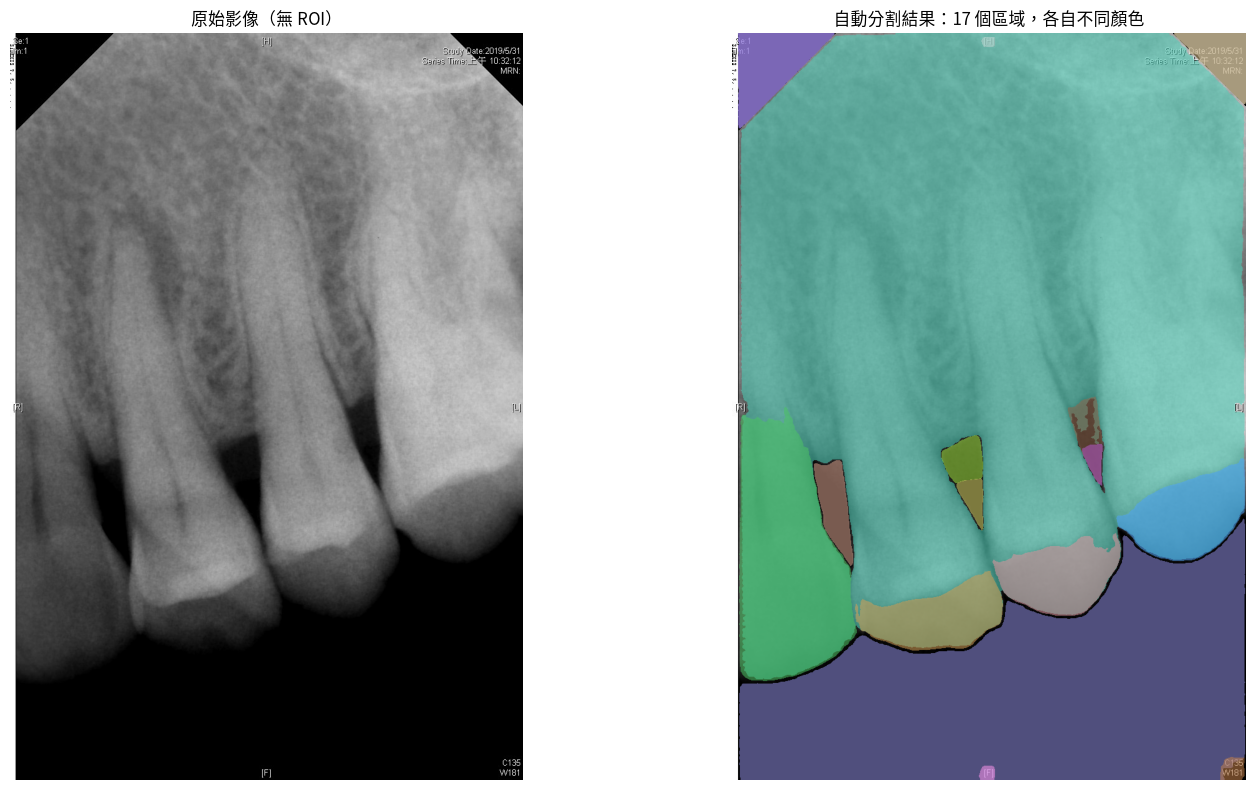

In [5]:
def colorize_masks(base_rgb: np.ndarray, masks: list[dict], alpha: float = 0.55, seed: int = 42):
    rng = np.random.default_rng(seed)
    overlay = base_rgb.astype(np.float32).copy()
    color_by_mask = []
    for m in sorted(masks, key=lambda m: m["area"], reverse=True):
        color = rng.integers(60, 256, size=3).astype(np.float32)
        seg = m["segmentation"]
        overlay[seg] = (1 - alpha) * overlay[seg] + alpha * color
        color_by_mask.append((m, color.astype(np.uint8)))
    return overlay.astype(np.uint8), color_by_mask


colored_overlay, color_by_mask = colorize_masks(sam_image, masks)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(sam_image)
axes[0].set_title("原始影像（無 ROI）")
axes[0].axis("off")
axes[1].imshow(colored_overlay)
axes[1].set_title(f"自動分割結果：{len(masks)} 個區域，各自不同顏色")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 5. 只畫邊界線：專門檢查邊緣品質

實心 overlay 適合看「分成幾塊」，但填色本身會蓋住底圖邊緣。這裡改成只畫每個 mask 的外輪廓線（`cv2.findContours` + `drawContours`），疊在原圖上，方便直接判斷 SAM 找到的邊界是否貼合牙齒／骨頭的真實邊緣，還是切在奇怪的地方。

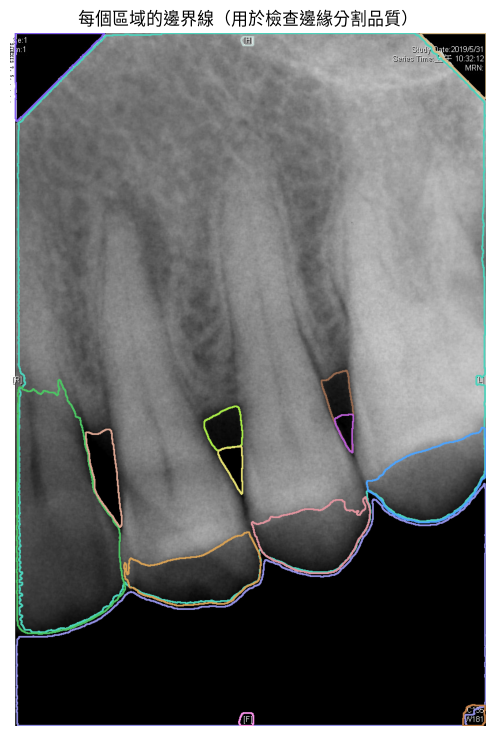

In [6]:
def draw_mask_contours(base_rgb: np.ndarray, color_by_mask, thickness: int = 2):
    edge_overlay = base_rgb.copy()
    for m, color in color_by_mask:
        seg = m["segmentation"].astype(np.uint8)
        contours, _ = cv2.findContours(seg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(edge_overlay, contours, -1, color.tolist(), thickness)
    return edge_overlay


edge_overlay = draw_mask_contours(sam_image, color_by_mask)

fig, ax = plt.subplots(figsize=(10, 9))
ax.imshow(edge_overlay)
ax.set_title("每個區域的邊界線（用於檢查邊緣分割品質）")
ax.axis("off")
plt.show()

## 6. 區域面積與分數分布

檢查是否有大量極小的雜訊區域，或分數（`predicted_iou` / `stability_score`）偏低的區域——這些通常對應邊界模糊、SAM 不確定的地方，值得放大檢查。

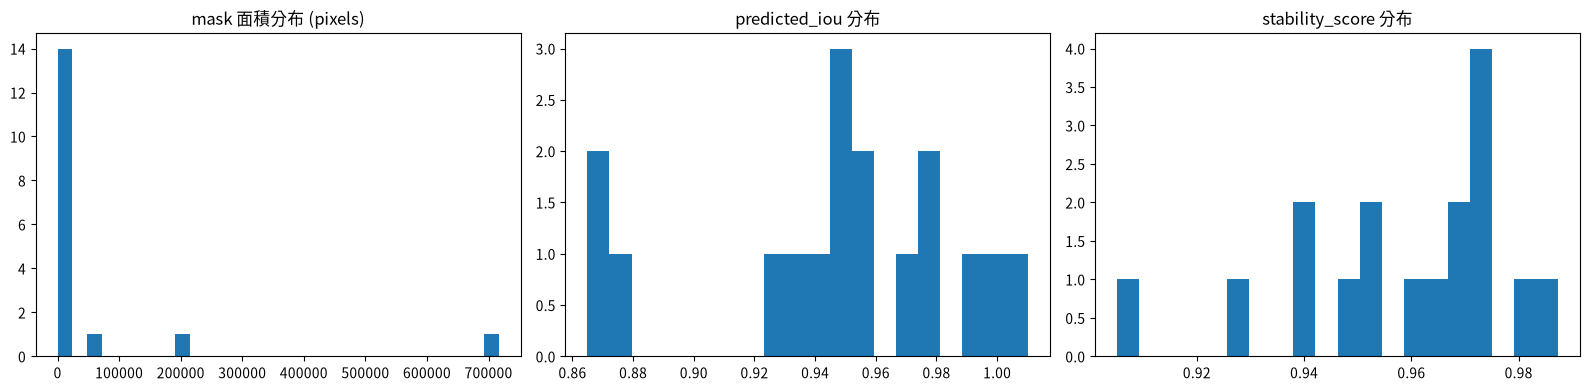

predicted_iou: mean=0.947, min=0.865
stability_score: mean=0.958, min=0.905


In [7]:
pred_ious = np.array([m["predicted_iou"] for m in masks])
stability = np.array([m["stability_score"] for m in masks])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(areas, bins=30)
axes[0].set_title("mask 面積分布 (pixels)")
axes[1].hist(pred_ious, bins=20)
axes[1].set_title("predicted_iou 分布")
axes[2].hist(stability, bins=20)
axes[2].set_title("stability_score 分布")
plt.tight_layout()
plt.show()

print(f"predicted_iou: mean={pred_ious.mean():.3f}, min={pred_ious.min():.3f}" if len(masks) else "無資料")
print(f"stability_score: mean={stability.mean():.3f}, min={stability.min():.3f}" if len(masks) else "無資料")

## 7. 輸出結果

存實心 overlay 與邊界線 overlay 兩張圖，方便之後比較不同參數或不同影像的分割效果。

In [8]:
colored_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_auto_seg_colored.png"
edges_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_auto_seg_edges.png"

cv2.imwrite(str(colored_path), cv2.cvtColor(colored_overlay, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(edges_path), cv2.cvtColor(edge_overlay, cv2.COLOR_RGB2BGR))

print("saved:", colored_path, edges_path, sep="\n- ")

saved:
- /home/cliffyang/Program/Medical-CV/tooth_ratio/reports/single_image/auto_seg/1_auto_seg_colored.png
- /home/cliffyang/Program/Medical-CV/tooth_ratio/reports/single_image/auto_seg/1_auto_seg_edges.png


## 8. 重點與後續調整方向

- 這裡用的是**通用** SAM ViT-B 權重，沒有針對牙科 X-ray 微調，所以區域切分不一定對齊「一顆牙」的解剖邊界，純粹用來檢查邊緣分割效果。
- 若邊界看起來太粗糙、漏掉細小牙根：調高 `points_per_side`（例如 48–64）、調低 `pred_iou_thresh` / `stability_score_thresh`，或設定 `crop_n_layers=1` 做多尺度分割，但推論時間會明顯增加。
- 若雜訊區域太多：提高分數門檻，或加大 `min_mask_region_area`。
- 若要看不同影像的效果差異，只需改第 0 節的 `IMAGE_PATH`（`data/raw_images/*.jpg` 或 `data/processed/*.png`）重新執行。
- 要得到「一顆牙一個 mask」的可用結果，仍建議走 `sigle_image.ipynb` / `src/core/segmentation/sam_infer.py` 的 box-prompt 流程，或先用 YOLO11（`reports/models/yolo11/tooth_detect/weights/best.pt`）偵測牙齒再逐顆丟給 SAM box prompt。